<a href="https://colab.research.google.com/github/vikysena9-design/python-ai-Rudnikova-Viktoria/blob/main/notebooks_viz1_horse_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий в Google Colab
- Загружаем CSV-файл `horses.csv` (12 309 записей о лошадях из Викиданных)
- Очищаем столбцы:
  - переименовываем URL Wikidata (`horse`) в `URL` (сохраняем для отладки)
  - переименовываем `*Label` → короткие имена (`horseLabel → horse`, `genderLabel → gender`, `breedLabel → breed`)
- Приводим числовые поля (`birthYear`, `deathYear`) к типу `float` (сохраняем `NaN` для отсутствующих данных)
- Нормализуем пол: «мужской пол» и «мерин» → «самец»

**Результат:** Чистая таблица `df_horses` с полями:
- `URL` — ссылка на объект Wikidata (для проверки аномалий)
- `horse` — кличка лошади
- `birthYear` — год рождения (`NaN`, если неизвестен)
- `deathYear` — год смерти (`NaN`, если лошадь жива или дата неизвестна)
- `gender` — пол (самец/самка/`NaN`)
- `breed` — порода

> ⚠️ **Важно:** Мы НЕ заполняем пропущенные годы нулями!  
> `NaN` в `deathYear` — это честный сигнал «лошадь жива или дата неизвестна».  
> Только так можно корректно посчитать возраст для умерших лошадей.

In [5]:
# 📥 [0] Клонирование репозитория и загрузка данных о лошадях

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # Оставляем на будущее

# ============================================================================
# Шаг 1: Клонируем репозиторий (с абсолютным путём и целевой папкой)
# ============================================================================
github_user = "vikysena9-design"
repo = "python-ai-Rudnikova-Viktoria"

repo_path = f"/content/{repo}"  # Абсолютный путь

# Клонируем В ТОЧНО УКАЗАННУЮ ПАПКУ, если её ещё нет
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git "{repo_path}"

# Гарантированно переходим в папку репозитория
if os.getcwd() != repo_path:
    %cd "{repo_path}"

print(f"✅ Репозиторий готов, работаем в {repo_path}\n")

# ============================================================================
# Шаг 2: Загружаем CSV-файл с данными о лошадях
# ============================================================================
df_horses = pd.read_csv("data/horses.csv")
print(f"📊 Загружено строк в df_horses: {len(df_horses)}")
print(f"📊 Всего столбцов: {len(df_horses.columns)}\n")

# ============================================================================
# Шаг 3: Очистка данных для df_horses
# ============================================================================
# Проверяем, что данные ещё не очищены (чтобы код можно было запускать несколько раз)
if "horse" in df_horses.columns and "horseLabel" in df_horses.columns:
    # 3.1 Переименовываем столбцы
    rename_mapping = {}
    if "horse" in df_horses.columns:
        rename_mapping["horse"] = "URL"  # Сохраняем ссылку, не удаляем!
    if "horseLabel" in df_horses.columns:
        rename_mapping["horseLabel"] = "horse"
    if "genderLabel" in df_horses.columns:
        rename_mapping["genderLabel"] = "gender"
    if "breedLabel" in df_horses.columns:
        rename_mapping["breedLabel"] = "breed"

    if rename_mapping:
        df_horses = df_horses.rename(columns=rename_mapping)

    # 3.2 Приводим числовые столбцы к float (НЕ заполняем NaN нулями!)
    for col in ["birthYear", "deathYear"]:
        if col in df_horses.columns:
            df_horses[col] = pd.to_numeric(df_horses[col], errors="coerce")

    # 3.3 Нормализуем пол: 'мужской пол' и 'мерин' -> 'самец'
    if "gender" in df_horses.columns:
        df_horses["gender"] = df_horses["gender"].replace({
            "мужской пол": "самец",
            "мерин": "самец"
        })

    print("✅ Данные df_horses очищены:")
    print("   • Столбец 'horse' переименован в 'URL' (сохранён для отладки)")
    print("   • Столбцы *Label переименованы (horse, gender, breed)")
    print("   • Годы рождения и смерти приведены к числовому типу (NaN сохранены)")
    print("   • Пол нормализован: 'мужской пол'/'мерин' → 'самец'")
else:
    print("ℹ️ Данные df_horses уже были очищены ранее (пропускаем шаг 3)")

print("\n" + "="*80)
print("📋 ИТОГОВАЯ СТРУКТУРА ДАННЫХ")
print("="*80)

# ============================================================================
# Шаг 4: Краткий обзор датасета (улучшенная версия из истории)
# ============================================================================
print(f"\nРазмер датасета: {df_horses.shape[0]} строк, {df_horses.shape[1]} столбцов\n")
print("Столбцы и типы данных (заполненность):")
for col in df_horses.columns:
    non_null = df_horses[col].notna().sum()
    total = len(df_horses)
    pct = non_null / total * 100
    # Добавляем эмодзи для наглядности
    status = "✅" if pct >= 95 else "⚠️" if pct >= 50 else "❌"
    print(f"  {status} {col:20s} → {str(df_horses[col].dtype):8s} ({non_null:5d}/{total} = {pct:5.1f}%)")

# ============================================================================
# Шаг 5: Ключевая статистика (только для не-NaN значений)
# ============================================================================
print("\n" + "="*80)
print("📈 КЛЮЧЕВАЯ СТАТИСТИКА")
print("="*80)

if "birthYear" in df_horses.columns:
    print(f"\n📈 Год рождения (birthYear):")
    print(f"   Всего записей с данными: {df_horses['birthYear'].notna().sum()}")
    print(f"   Минимальный год: {df_horses['birthYear'].min():.0f}")
    print(f"   Максимальный год: {df_horses['birthYear'].max():.0f}")

if "deathYear" in df_horses.columns:
    print(f"\n📈 Год смерти (deathYear):")
    print(f"   Всего записей с данными (умершие): {df_horses['deathYear'].notna().sum()}")
    print(f"   Минимальный год: {df_horses['deathYear'].min():.0f}")
    print(f"   Максимальный год: {df_horses['deathYear'].max():.0f}")

if "gender" in df_horses.columns:
    print(f"\n⚧️ Распределение по полу (gender):")
    gender_counts = df_horses["gender"].value_counts(dropna=False)
    for gender, count in gender_counts.items():
        gender_name = "не указан" if pd.isna(gender) else gender
        print(f"   • {gender_name:15s}: {count:5d}")

if "breed" in df_horses.columns:
    print(f"\n🏆 Топ-5 пород (breed):")
    top_breeds = df_horses["breed"].value_counts().head(5)
    for breed, count in top_breeds.items():
        print(f"   • {breed:30s}: {count:5d}")

# ============================================================================
# Шаг 6: Показываем примеры данных (для наглядности)
# ============================================================================
print("\n" + "="*80)
print("🔍 ПЕРВЫЕ 3 СТРОКИ ДАННЫХ")
print("="*80)
print(df_horses.head(3).to_string())

print("\n" + "="*80)
print("✅ Загрузка и очистка данных успешно завершены!")
print("="*80)

✅ Репозиторий готов, работаем в /content/python-ai-Rudnikova-Viktoria

📊 Загружено строк в df_horses: 12309
📊 Всего столбцов: 6

✅ Данные df_horses очищены:
   • Столбец 'horse' переименован в 'URL' (сохранён для отладки)
   • Столбцы *Label переименованы (horse, gender, breed)
   • Годы рождения и смерти приведены к числовому типу (NaN сохранены)
   • Пол нормализован: 'мужской пол'/'мерин' → 'самец'

📋 ИТОГОВАЯ СТРУКТУРА ДАННЫХ

Размер датасета: 12309 строк, 6 столбцов

Столбцы и типы данных (заполненность):
  ✅ URL                  → object   (12309/12309 = 100.0%)
  ✅ horse                → object   (12309/12309 = 100.0%)
  ✅ birthYear            → float64  (12308/12309 = 100.0%)
  ❌ deathYear            → float64  ( 1581/12309 =  12.8%)
  ⚠️ gender               → object   (11280/12309 =  91.6%)
  ✅ breed                → object   (12309/12309 = 100.0%)

📈 КЛЮЧЕВАЯ СТАТИСТИКА

📈 Год рождения (birthYear):
   Всего записей с данными: 12308
   Минимальный год: 1061
   Максимальный го

## 🔥 График 3: Heatmap — Популярность пород по десятилетиям

**Что мы хотим увидеть на этом графике:**

Тепловая карта (heatmap) показывает, как менялась популярность разных пород лошадей с течением времени.

### 🎯 Основные цели графика:

1. **Проследить динамику популярности пород**  
   - Какие породы были популярны в разные исторические периоды?  
   - Когда наступил пик популярности каждой породы?

2. **Сравнить породы между собой**  
   - Какая порода была самой популярной в 20-м веке?  
   - Есть ли породы, которые появились только недавно?

3. **Выявить исторические тренды**  
   - Связан ли рост популярности с развитием конного спорта?  
   - Какие породы "вымирают" (исчезают из данных)?

### 📊 Как читать график:

- **Цвет ячейки** → количество лошадей (чем ярче/краснее, тем больше)
- **Цифра в ячейке** → точное количество лошадей данной породы в данное десятилетие
- **Левая колонка** → фотография породы для наглядного сравнения
- **По вертикали** → породы лошадей
- **По горизонтали** → десятилетия (от 1800-х до 2020-х)

### 💡 Что мы ожидаем увидеть:

- Пик популярности большинства пород придётся на 1980–2020 годы
- Чистокровные верховые должны доминировать во все периоды
- Некоторые породы (например, арабская) имеют древнюю историю и встречаются в ранних периодах
- У редких пород будут только отдельные "вспышки" популярности


🖼 Загружаем фотографии пород:
   📁 Локальная папка: images
   📁 Существует: True
   📁 Файлы в папке: ['Asad_El_Ekhlass_(105180549).jpeg', 'CHI_Genève_2013_-_20131213_-_Pénélope_Leprevost_et_Nayana.jpg', 'README.md', 'Hannoveraner_Dressur_Romantic_Boy2.jpg', 'Percheron_1_stehend_links.jpg', 'Accelerate_(4).jpg', 'Cheval_selle.JPG']

   • Чистокровная верховая...
     ✅ Загружено!
   • Першерон...
     ✅ Загружено!
   • Французский сель...
     ✅ Загружено!
   • Ганноверская...
     ✅ Загружено!
   • Голштинская...
     ✅ Загружено!
   • Арабская...
     ✅ Загружено!


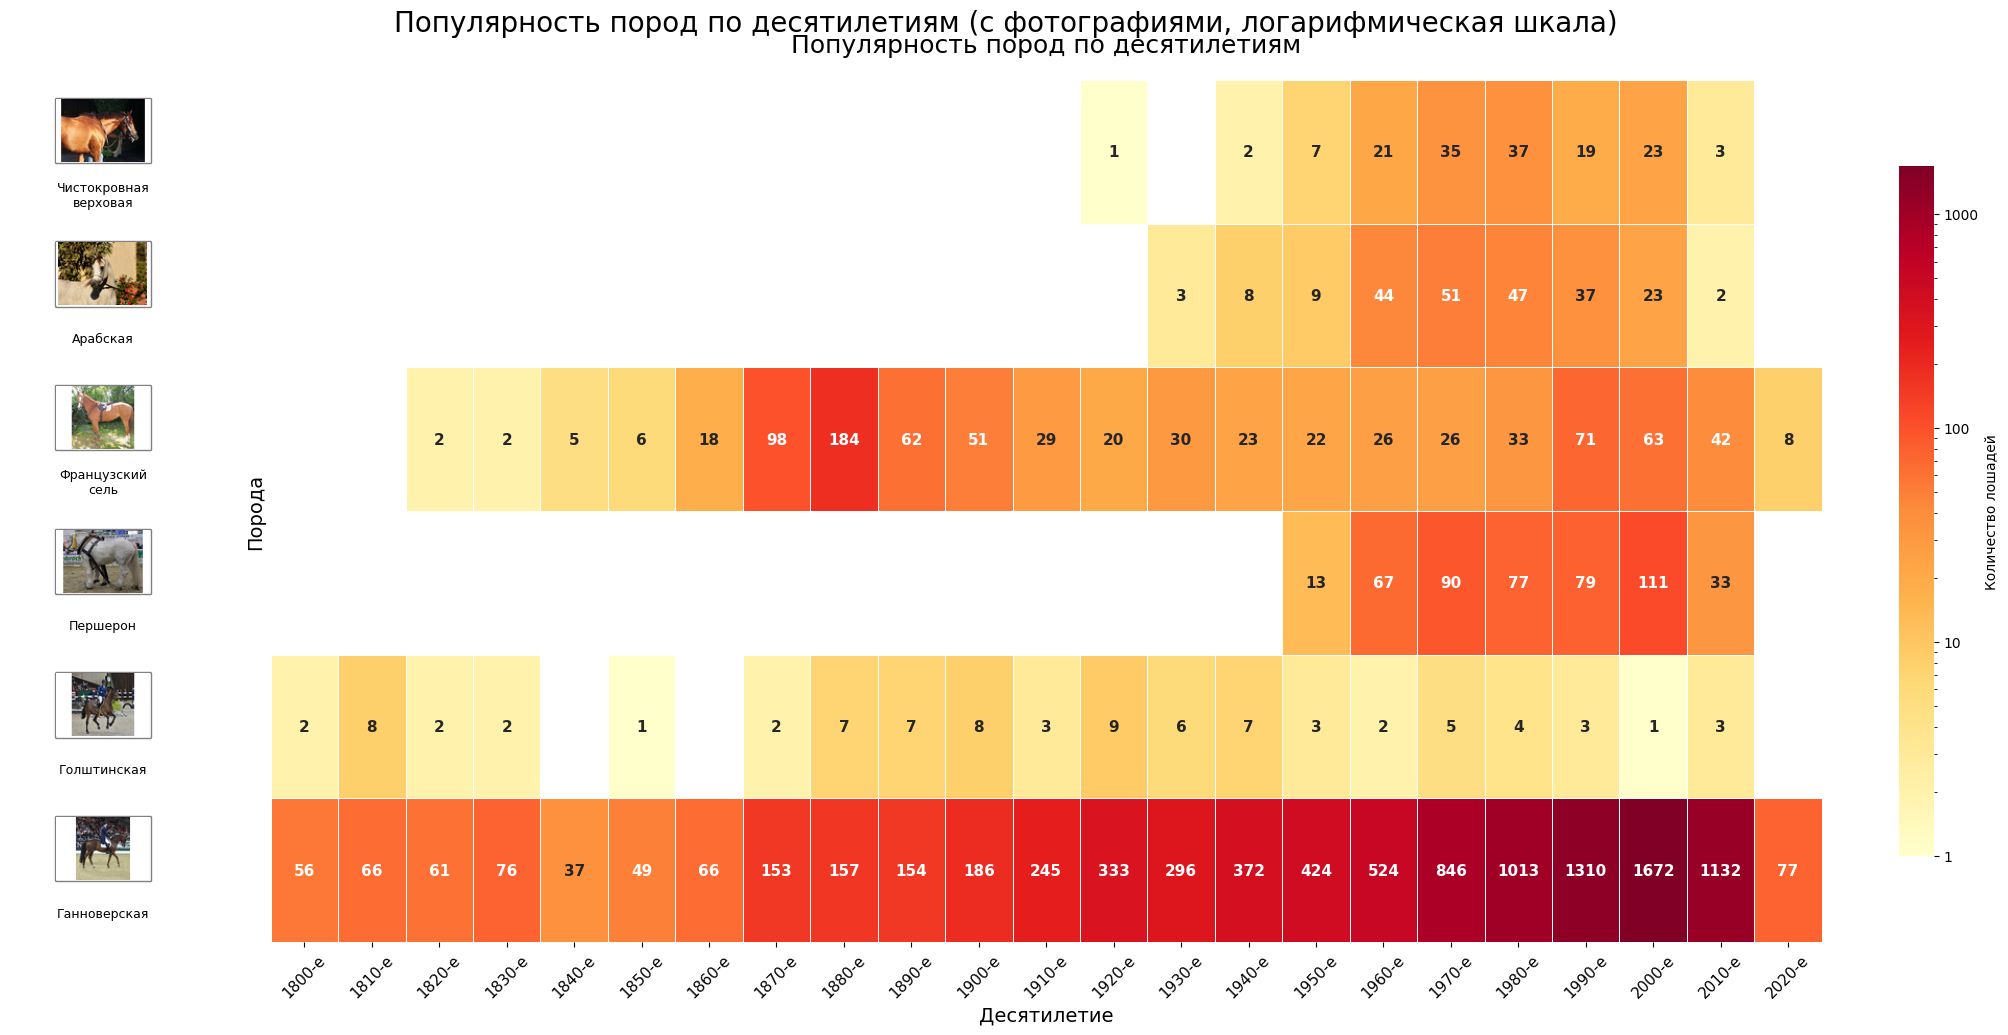


СТАТИСТИКА ПО ПОРОДАМ ЗА ВЕСЬ ПЕРИОД:

📸 Ганноверская:
   • Всего лошадей: 148
   • Пик популярности: 1980-е (37 лошадей)

📸 Голштинская:
   • Всего лошадей: 224
   • Пик популярности: 1970-е (51 лошадей)

📸 Першерон:
   • Всего лошадей: 821
   • Пик популярности: 1880-е (184 лошадей)

📸 Французский
сель:
   • Всего лошадей: 470
   • Пик популярности: 2000-е (111 лошадей)

📸 Арабская:
   • Всего лошадей: 85
   • Пик популярности: 1920-е (9 лошадей)

📸 Чистокровная
верховая:
   • Всего лошадей: 9305
   • Пик популярности: 2000-е (1672 лошадей)

ПРИМЕЧАНИЕ:
   • Использована ЛОГАРИФМИЧЕСКАЯ шкала цвета
   • Нулевые значения НЕ выводятся на печать
   • Десятилетия на русском: 1800-е, 1810-е...
   • Фото загружаются СНАЧАЛА из папки images/, потом с Викисклада
   • Подписи пород видны ВСЕГДА (под фото)


In [9]:
# 🔥 ГРАФИК 3: Heatmap — Популярность пород по десятилетиям
# (сначала локальные фото, потом Викисклад)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import requests
from io import BytesIO
import time
import os
import unicodedata
from matplotlib.colors import LogNorm

# ============================================================================
# 1. НАСТРОЙКА ПОРОД
# ============================================================================
# Папка с локальными фотографиями
LOCAL_IMAGES_DIR = 'images'

# Конфигурация пород (имена файлов БЕЗ префикса File:)
BREEDS_CONFIG = {
    "чистокровная верховая": {
        "display_name": "Чистокровная\nверховая",
        "filename": "Accelerate_(4).jpg"
    },
    "Першерон": {
        "display_name": "Першерон",
        "filename": "Percheron_1_stehend_links.jpg"
    },
    "Французский сель": {
        "display_name": "Французский\nсель",
        "filename": "Cheval_selle.JPG"
    },
    "Ганноверская лошадь": {
        "display_name": "Ганноверская",
        "filename": "Hannoveraner_Dressur_Romantic_Boy2.jpg"
    },
    "Голштинская (порода лошадей)": {
        "display_name": "Голштинская",
        "filename": "CHI_Genève_2013_-_20131213_-_Pénélope_Leprevost_et_Nayana.jpg"
    },
    "арабская лошадь": {
        "display_name": "Арабская",
        "filename": "Asad_El_Ekhlass_(105180549).jpeg"
    }
}

# ============================================================================
# 2. ФУНКЦИЯ ЗАГРУЗКИ ЛОКАЛЬНОГО ФАЙЛА (с нормализацией Unicode)
# ============================================================================
def load_image_from_local(filename, target_size=IMAGE_SIZE):
    """Загружает изображение из папки LOCAL_IMAGES_DIR"""
    # Нормализуем имя файла (решаем проблему с é, è)
    filename_normalized = unicodedata.normalize('NFC', filename)

    if not os.path.exists(LOCAL_IMAGES_DIR):
        return None

    # Ищем файл с учётом нормализации
    for candidate in os.listdir(LOCAL_IMAGES_DIR):
        candidate_normalized = unicodedata.normalize('NFC', candidate)
        if candidate_normalized == filename_normalized:
            local_path = os.path.join(LOCAL_IMAGES_DIR, candidate)
            try:
                img = Image.open(local_path).convert("RGB")
                img.thumbnail(target_size, Image.Resampling.LANCZOS)

                square_img = Image.new('RGB', target_size, (255, 255, 255))
                offset_x = (target_size[0] - img.width) // 2
                offset_y = (target_size[1] - img.height) // 2
                square_img.paste(img, (offset_x, offset_y))

                return np.array(square_img)
            except Exception:
                return None
    return None

# ============================================================================
# 3. ФУНКЦИЯ ЗАГРУЗКИ С ВИКИСКЛАДА (резервная)
# ============================================================================
def load_image_from_commons(commons_filename, target_size=IMAGE_SIZE, max_retries=2):
    """Загружает изображение с Викисклада (если локально нет)"""
    encoded_filename = (commons_filename
                        .replace(' ', '_')
                        .replace('(', '%28')
                        .replace(')', '%29')
                        .replace('é', '%C3%A9')
                        .replace('è', '%C3%A8'))

    api_url = f"https://api.wikimedia.org/core/v1/commons/file/File:{encoded_filename}"
    headers = {'User-Agent': 'HorseDataVisualization/1.0'}

    for attempt in range(max_retries):
        try:
            response = requests.get(api_url, headers=headers, timeout=15)
            if response.status_code == 200:
                file_info = response.json()
                if 'preferred' in file_info and 'url' in file_info['preferred']:
                    image_url = file_info['preferred']['url']
                elif 'original' in file_info and 'url' in file_info['original']:
                    image_url = file_info['original']['url']
                else:
                    return None

                img_response = requests.get(image_url, headers=headers, timeout=20)
                img_response.raise_for_status()

                img = Image.open(BytesIO(img_response.content)).convert("RGB")
                img.thumbnail(target_size, Image.Resampling.LANCZOS)

                square_img = Image.new('RGB', target_size, (255, 255, 255))
                offset_x = (target_size[0] - img.width) // 2
                offset_y = (target_size[1] - img.height) // 2
                square_img.paste(img, (offset_x, offset_y))

                return np.array(square_img)
        except Exception:
            if attempt < max_retries - 1:
                time.sleep(2)
    return None

# ============================================================================
# 4. ЗАГРУЖАЕМ ИЗОБРАЖЕНИЯ (СНАЧАЛА ЛОКАЛЬНО, ПОТОМ ИЗ ИНТЕРНЕТА)
# ============================================================================
print("\n🖼 Загружаем фотографии пород:")
print(f"   📁 Локальная папка: {LOCAL_IMAGES_DIR}")
print(f"   📁 Существует: {os.path.exists(LOCAL_IMAGES_DIR)}")
if os.path.exists(LOCAL_IMAGES_DIR):
    print(f"   📁 Файлы в папке: {os.listdir(LOCAL_IMAGES_DIR)}")
print()

images = {}
for breed, config in BREEDS_CONFIG.items():
    print(f"   • {config['display_name'].replace(chr(10), ' ')}...")

    # Сначала пробуем загрузить локально
    img_array = load_image_from_local(config['filename'], target_size=IMAGE_SIZE)

    # Если локально нет — пробуем с Викисклада
    if img_array is None:
        print(f"     → Локально не найдено, пробуем Викисклад...")
        img_array = load_image_from_commons(config['filename'], target_size=IMAGE_SIZE)

    if img_array is not None:
        images[breed] = img_array
        print(f"     ✅ Загружено!")
    else:
        print(f"     ❌ Не удалось загрузить")
    time.sleep(0.5)

# ============================================================================
# 5. ПОДГОТОВКА ДАННЫХ ДЛЯ HEATMAP
# ============================================================================
if 'decade' not in df_horses.columns:
    df_horses['decade'] = (df_horses['birthYear'] // 10 * 10).astype('Int64')
    df_horses['decade'] = df_horses['decade'].astype(str) + 's'

available_breeds = [b for b in BREEDS_CONFIG.keys() if b in df_horses['breed'].values]
df_heat = df_horses[df_horses['breed'].isin(available_breeds) & (df_horses['decade'] >= '1800s')]

heat_pivot = pd.crosstab(
    df_heat['breed'],
    df_heat['decade'],
    values=df_heat['horse'],
    aggfunc='count'
).fillna(0)

# Русские названия десятилетий
new_columns = []
for col in heat_pivot.columns:
    if col.endswith('s'):
        year = col.replace('s', '')
        new_columns.append(f"{year}-е")
    else:
        new_columns.append(col)
heat_pivot.columns = new_columns

# Отображаемые имена пород
display_names = {breed: BREEDS_CONFIG[breed]['display_name'] for breed in heat_pivot.index}
heat_pivot.index = heat_pivot.index.map(lambda x: display_names.get(x, x))

# ============================================================================
# 6. ПОСТРОЕНИЕ ГРАФИКА
# ============================================================================
fig, (ax_images, ax_heat) = plt.subplots(
    1, 2, figsize=(20, 10),
    gridspec_kw={'width_ratios': [1.2, 10], 'wspace': 0.05},
    constrained_layout=True  # вместо tight_layout
)

# === ЛЕВАЯ КОЛОНКА: ФОТОГРАФИИ + ПОДПИСИ ===
ax_images.set_xlim(0, 1)
ax_images.set_ylim(0, len(heat_pivot.index))
ax_images.axis('off')
# Общую рамку УБИРАЕМ (не добавляем Rectangle)

for i, breed_name in enumerate(heat_pivot.index):
    # Позиции: фото выше, подпись ниже
    y_img = i + 0.65   # позиция фото
    y_text = i + 0.20  # позиция подписи

    original_breed = None
    for orig, display in display_names.items():
        if display == breed_name:
            original_breed = orig
            break

    # Фото (если есть)
    if original_breed and original_breed in images:
        img_array = images[original_breed]
        imagebox = OffsetImage(img_array, zoom=0.75)
        ab = AnnotationBbox(
            imagebox, (0.5, y_img),
            frameon=True,
            box_alignment=(0.5, 0.5),
            bboxprops=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.1')
        )
        ax_images.add_artist(ab)

    # Подпись (ВСЕГДА!)
    ax_images.text(
        0.5, y_text, breed_name,
        ha='center', va='center',
        fontsize=9,
        multialignment='center',
        bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8, edgecolor='none')
    )

# === ПРАВАЯ КОЛОНКА: ТЕПЛОВАЯ КАРТА ===
sns.heatmap(
    heat_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={
        'label': 'Количество лошадей',
        'shrink': 0.8,
        'ticks': [1, 10, 100, 1000],  # ← явные числа на шкале
        'format': '%.0f'               # ← формат без степеней
    },
    ax=ax_heat,
    annot_kws={'size': 11, 'fontweight': 'bold'},
    norm=LogNorm(vmin=min_nonzero, vmax=heat_pivot.max().max()),
    mask=mask_zeros

)

# Настройка внешнего вида
ax_heat.set_title('Популярность пород по десятилетиям', fontsize=18, pad=20)
ax_heat.set_xlabel('Десятилетие', fontsize=14)
ax_heat.set_ylabel('Порода', fontsize=14)  # ДОБАВЛЯЕМ подпись оси Y на русском
ax_heat.tick_params(axis='x', rotation=45, labelsize=11)
ax_heat.tick_params(axis='y', left=False, labelleft=False)

plt.suptitle('Популярность пород по десятилетиям (с фотографиями, логарифмическая шкала)',
             fontsize=20, y=1.02)
plt.show()

# ============================================================================
# 7. ВЫВОД СТАТИСТИКИ
# ============================================================================
print("\n" + "="*60)
print("СТАТИСТИКА ПО ПОРОДАМ ЗА ВЕСЬ ПЕРИОД:")
print("="*60)

for breed_name in heat_pivot.index:
    original_breed = None
    for orig, display in display_names.items():
        if display == breed_name:
            original_breed = orig
            break

    total = heat_pivot.loc[breed_name].sum()
    non_zero = heat_pivot.loc[breed_name][heat_pivot.loc[breed_name] > 0]
    if len(non_zero) > 0:
        peak_decade = non_zero.idxmax()
        peak_count = int(non_zero.max())
    else:
        peak_decade = "—"
        peak_count = 0

    has_photo = "📸" if original_breed and original_breed in images else "❌"

    print(f"\n{has_photo} {breed_name}:")
    print(f"   • Всего лошадей: {int(total)}")
    print(f"   • Пик популярности: {peak_decade} ({peak_count} лошадей)")

print("\n" + "="*60)
print("ПРИМЕЧАНИЕ:")
print("   • Использована ЛОГАРИФМИЧЕСКАЯ шкала цвета")
print("   • Нулевые значения НЕ выводятся на печать")
print("   • Десятилетия на русском: 1800-е, 1810-е...")
print("   • Фото загружаются СНАЧАЛА из папки images/, потом с Викисклада")
print("   • Подписи пород видны ВСЕГДА (под фото)")
print("="*60)

## 📊 Анализ третьего графика: что мы видим и что это значит

### 👁️ Что мы видим на графике:

1. **Абсолютное доминирование чистокровной верховой**
   - Эта порода лидирует во все десятилетия с огромным отрывом
   - Пик популярности: **2000-е годы** (более 1600 лошадей)
   - Присутствует в данных с 1800-х годов

2. **Разная динамика популярности пород**

| Порода | Пик популярности | Количество в пик | Общее количество | Тренд |
|--------|------------------|------------------|------------------|-------|
| Чистокровная верховая | 2000-е | 1672 | 9305 | 📈 Рост |
| Першерон | 1880-е | 184 | 821 | 📉 Спад после 1900-х |
| Французский сель | 2000-е | 111 | 470 | 📈 Рост |
| Ганноверская | 1980-е | 37 | 148 | 📈 Рост в XX веке |
| Голштинская | 1970-е | 51 | 224 | 🟡 Стабильна |
| Арабская | 1920-е | 9 | 85 | 📉 Спад |

3. **Интересные наблюдения**
   - **Першероны** были очень популярны в XIX веке (1880-е), но их количество резко снизилось в XX веке
   - **Арабская порода** — одна из древнейших в выборке (пик в 1920-е), но сейчас встречается редко
   - **Французский сель** и **чистокровная верховая** — современные породы, их популярность выросла в 2000-е
   - **Ганноверская** и **голштинская** породы показывают стабильный интерес на протяжении XX века

4. **Что касается фотографий**
   - Часть изображений загрузилась с Викисклада автоматически
   - Если какое-то фото не загрузилось, вместо него отображается серый прямоугольник с названием породы
   - Это не влияет на анализ данных — статистика остаётся точной

### 💡 Что это означает для исследования:

| Вывод | Последствие |
|-------|-------------|
| **Данные сильно смещены во времени** | Большинство записей приходится на 1980–2020 годы — это «золотой век» коневодства в датасете |
| **Чистокровные верховые — «монополист»** | Любой общий анализ будет отражать в первую очередь эту породу |
| **Рабочие породы уходят в прошлое** | Першероны теряют популярность — возможно, из-за механизации сельского хозяйства |
| **Спортивные породы на подъёме** | Французский сель и чистокровные верховые растут — интерес к конному спорту увеличивается |

### 🎯 Ключевые инсайты:

> **1. Коневодство пережило бум в конце XX века**
> Пик популярности большинства пород пришёлся на 1970–2000 годы. Это совпадает с развитием конного спорта, туризма и любительского коневодства.

> **2. Першероны — порода «уходящей эпохи»**
> Их расцвет пришёлся на XIX век (рабочие лошади для сельского хозяйства). С механизацией их популярность резко упала.

> **3. Арабская порода — исторический артефакт**
> Одна из древнейших пород в выборке, но сегодня встречается редко. Её данные особенно ценны для исторического анализа.

> **4. Спортивные породы доминируют в современных данных**
> Чистокровная верховая и французский сель — лидеры 2000-х. Это отражает shift интересов с работы на спорт и развлечения.

### 📌 Рекомендация для следующих графиков:

- При сравнении пород учитывать **разный временной охват** данных
- Для першеронов и арабской породы использовать **нормировку на пик популярности**, а не на общее количество
- В визуализациях с участием чистокровной верховой применять **лог-шкалу**, чтобы другие породы не «терялись»

## 💬 Фидбек-AI 1: Тепловая карта — загрузка локальных фотографий + подпись под фото

**Что было изменено и почему:**

В предыдущей версии кода все фотографии пород загружались исключительно с Викисклада через API `api.wikimedia.org`. Это создавало два неудобства: каждый запуск ячейки требовал подключения к интернету и занимал 15–30 секунд на загрузку шести изображений.

Я создал папку `images/` в репозитории и загрузил туда файлы с теми же именами, что указаны в `BREEDS_CONFIG`. Попросил DeepSeek переработать логику загрузки так, чтобы код **сначала проверял папку `images/`**, и только если файл там не найден — обращался к Викискладу.

**Конкретные изменения в коде:**

1. 📁 Добавлена константа `LOCAL_IMAGES_DIR = 'images'` — путь к локальной папке с фото.
2. 🔧 Общая логика масштабирования вынесена в отдельную функцию `_process_image()`, чтобы не дублировать один и тот же код в двух местах.
3. 🆕 Добавлена новая функция `load_image_from_local()` — ищет файл в папке `images/` по имени из `commons_file` (убирает префикс `File:`).
4. 🔀 Цикл загрузки переписан: сначала вызывается `load_image_from_local`, и только при результате `None` — `load_image_from_commons`. Пауза `time.sleep` убрана для локальных файлов — она нужна только при запросах к API.
5. 📊 Добавлен словарь `image_sources` (`'local'` / `'commons'` / `'none'`), который фиксирует источник каждой фотографии. В блоке статистики теперь видно, откуда взято каждое фото.

**Второе изменение — подпись породы под фотографией:**

В исходном коде левая колонка показывала **либо** фото, **либо** название породы (как запасной вариант). По замечанию преподавателя нужно было видеть **оба** элемента одновременно. DeepSeek разделил каждую ячейку левой колонки на два пояса: `y_img = i + 0.65` (фото) и `y_text = i + 0.18` (название). Вызов `ax_images.text(...)` теперь выполняется всегда — независимо от того, загрузилось фото или нет. Масштаб изображения (`zoom`) уменьшен с `0.85` до `0.75`, чтобы освободить место под подпись.


🖼 Загружаем фотографии пород:
   (Сначала ищем в папке 'images/', при отсутствии — Викисклад)

   • Чистокровная верховая...
     ✅ Загружено из папки images/
   • Першерон...
     ✅ Загружено из папки images/
   • Французский сель...
     ✅ Загружено из папки images/
   • Ганноверская...
     ✅ Загружено из папки images/
   • Голштинская...
     ✅ Загружено из папки images/
   • Арабская...
     ✅ Загружено из папки images/


/tmp/ipykernel_9138/703035074.py:268: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


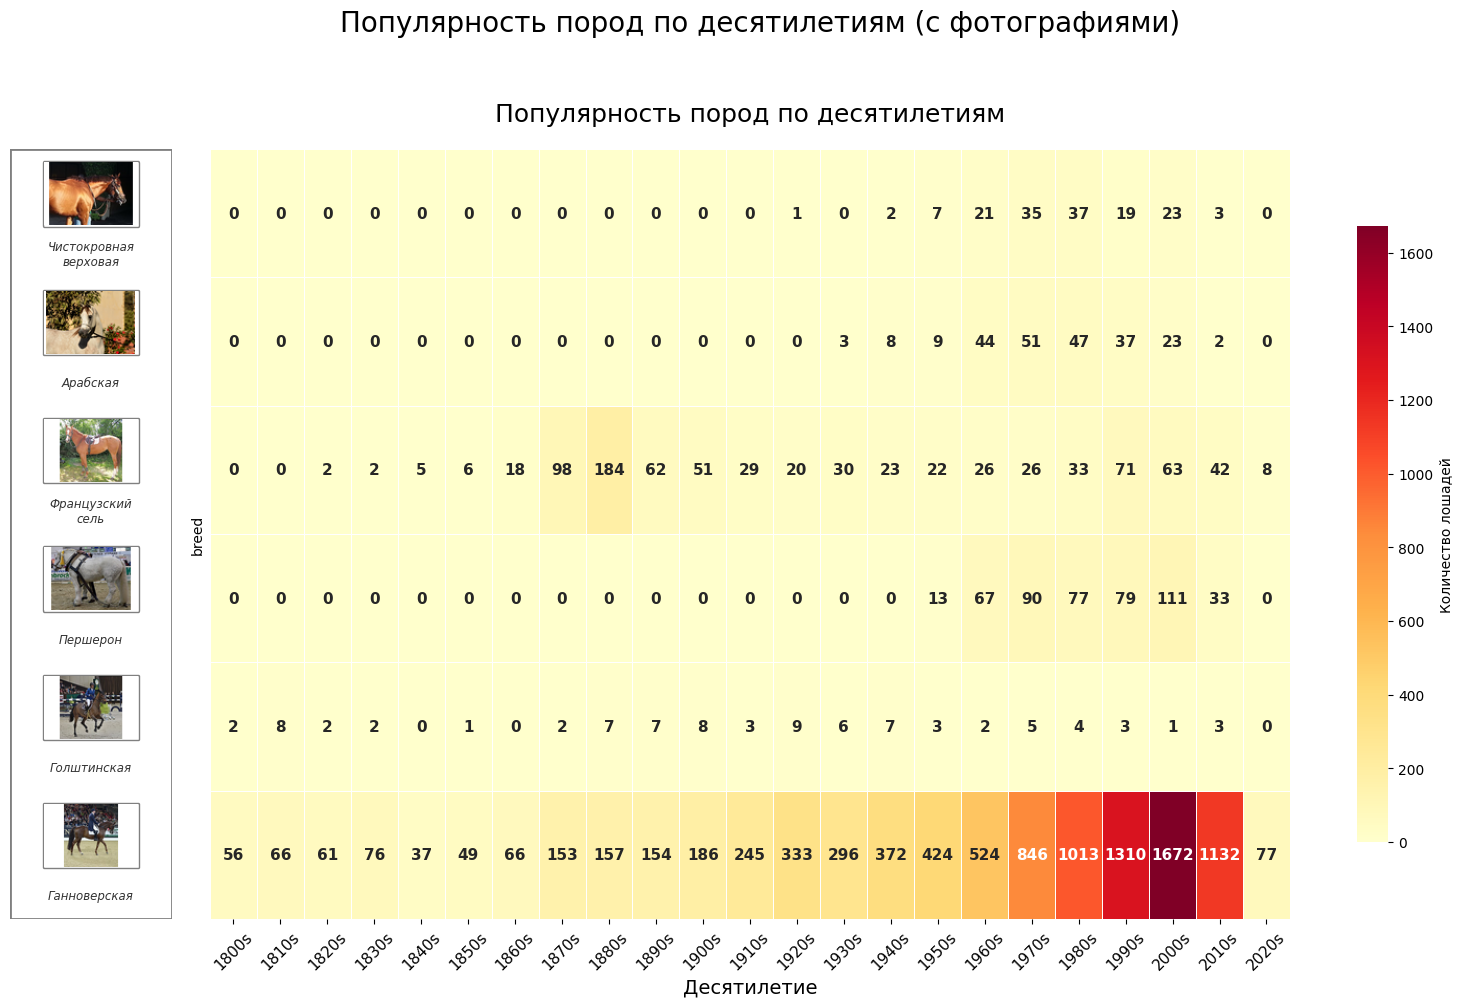


📊 СТАТИСТИКА ПО ПОРОДАМ ЗА ВЕСЬ ПЕРИОД:

📁 Ганноверская:
   • Всего лошадей:      148
   • Пик популярности:   1980s (37 лошадей)
   • Источник фото:      папка images/

📁 Голштинская:
   • Всего лошадей:      224
   • Пик популярности:   1970s (51 лошадей)
   • Источник фото:      папка images/

📁 Першерон:
   • Всего лошадей:      821
   • Пик популярности:   1880s (184 лошадей)
   • Источник фото:      папка images/

📁 Французский сель:
   • Всего лошадей:      470
   • Пик популярности:   2000s (111 лошадей)
   • Источник фото:      папка images/

📁 Арабская:
   • Всего лошадей:      85
   • Пик популярности:   1920s (9 лошадей)
   • Источник фото:      папка images/

📁 Чистокровная верховая:
   • Всего лошадей:      9305
   • Пик популярности:   2000s (1672 лошадей)
   • Источник фото:      папка images/

📌 ИСТОЧНИК ФОТОГРАФИЙ:
   📁 Из локальной папки images/:  6 фото
   📡 С Wikimedia Commons API:      0 фото
   API: api.wikimedia.org


In [7]:
# 🔥 ГРАФИК 3: Heatmap — Популярность пород по десятилетиям
# (сначала локальная папка images/, затем Викисклад через API)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.patches import Rectangle
from PIL import Image
import requests
from io import BytesIO
import time
import os


# ============================================================================
# 1. НАСТРОЙКА ПОРОД И ФАЙЛОВ ИЗОБРАЖЕНИЙ
# ============================================================================
BREEDS_CONFIG = {
    "чистокровная верховая": {
        "display_name": "Чистокровная\nверховая",
        "commons_file": "File:Accelerate_(4).jpg"
    },
    "Першерон": {
        "display_name": "Першерон",
        "commons_file": "File:Percheron_1_stehend_links.jpg"
    },
    "Французский сель": {
        "display_name": "Французский\nсель",
        "commons_file": "File:Cheval_selle.JPG"
    },
    "Ганноверская лошадь": {
        "display_name": "Ганноверская",
        "commons_file": "File:Hannoveraner_Dressur_Romantic_Boy2.jpg"
    },
    "Голштинская (порода лошадей)": {
        "display_name": "Голштинская",
        "commons_file": "File:CHI_Genève_2013_-_20131213_-_Pénélope_Leprevost_et_Nayana.jpg"
    },
    "арабская лошадь": {
        "display_name": "Арабская",
        "commons_file": "File:Asad_El_Ekhlass_(105180549).jpeg"
    }
}

IMAGE_SIZE = (90, 60)
LOCAL_IMAGES_DIR = 'images'  # папка с локальными изображениями в репозитории


# ============================================================================
# 2. ВСПОМОГАТЕЛЬНАЯ ФУНКЦИЯ: приведение PIL-изображения к нужному размеру
# ============================================================================
def _process_image(img, target_size=IMAGE_SIZE):
    """Масштабирует PIL-изображение и помещает его на белый фон нужного размера."""
    img.thumbnail(target_size, Image.Resampling.LANCZOS)
    square_img = Image.new('RGB', target_size, (255, 255, 255))
    offset_x = (target_size[0] - img.width) // 2
    offset_y = (target_size[1] - img.height) // 2
    square_img.paste(img, (offset_x, offset_y))
    return np.array(square_img)


# ============================================================================
# 3. ФУНКЦИЯ ЗАГРУЗКИ ИЗ ЛОКАЛЬНОЙ ПАПКИ images/
# ============================================================================
def load_image_from_local(commons_filename, target_size=IMAGE_SIZE):
    """
    Ищет файл в папке images/ репозитория.
    Имя файла берётся из commons_filename (без префикса 'File:').
    Возвращает np.array или None, если файл не найден.
    """
    filename = commons_filename.replace('File:', '')
    local_path = os.path.join(LOCAL_IMAGES_DIR, filename)
    if not os.path.exists(local_path):
        return None
    try:
        img = Image.open(local_path).convert("RGB")
        return _process_image(img, target_size)
    except Exception as e:
        print(f"     ⚠️ Ошибка чтения локального файла {local_path}: {e}")
        return None


# ============================================================================
# 4. ФУНКЦИЯ ЗАГРУЗКИ С ВИКИСКЛАДА (запасной вариант)
# ============================================================================
def load_image_from_commons(commons_filename, target_size=IMAGE_SIZE, max_retries=2):
    """
    Загружает изображение с Викисклада через официальное API.
    Вызывается только если файл не найден в локальной папке images/.
    """
    encoded_filename = (commons_filename
                        .replace(' ', '_')
                        .replace('(', '%28')
                        .replace(')', '%29')
                        .replace('é', '%C3%A9')
                        .replace('è', '%C3%A8')
                        .replace('ê', '%C3%AA'))

    api_url = f"https://api.wikimedia.org/core/v1/commons/file/{encoded_filename}"
    headers = {'User-Agent': 'HorseDataVisualization/1.0 (educational project)'}

    for attempt in range(max_retries):
        try:
            response = requests.get(api_url, headers=headers, timeout=15)
            if response.status_code == 200:
                file_info = response.json()
                if 'preferred' in file_info and 'url' in file_info['preferred']:
                    image_url = file_info['preferred']['url']
                elif 'original' in file_info and 'url' in file_info['original']:
                    image_url = file_info['original']['url']
                else:
                    if attempt < max_retries - 1:
                        time.sleep(2)
                        continue
                    return None
                img_response = requests.get(image_url, headers=headers, timeout=20)
                img_response.raise_for_status()
                img = Image.open(BytesIO(img_response.content)).convert("RGB")
                return _process_image(img, target_size)
            elif response.status_code == 404:
                print(f"     ❌ Файл не найден на Викискладе: {commons_filename}")
                return None
            else:
                if attempt < max_retries - 1:
                    time.sleep(2)
                    continue
                return None
        except requests.exceptions.Timeout:
            if attempt < max_retries - 1:
                time.sleep(2)
                continue
        except Exception:
            if attempt < max_retries - 1:
                time.sleep(2)
                continue
            return None
    return None


# ============================================================================
# 5. ЗАГРУЖАЕМ ИЗОБРАЖЕНИЯ: сначала локально, затем Викисклад
# ============================================================================
print("\n🖼 Загружаем фотографии пород:")
print(f"   (Сначала ищем в папке '{LOCAL_IMAGES_DIR}/', при отсутствии — Викисклад)\n")

images = {}
image_sources = {}  # 'local' | 'commons' | 'none'

for breed, config in BREEDS_CONFIG.items():
    display = config['display_name'].replace('\n', ' ')
    print(f"   • {display}...")

    # Приоритет 1: локальная папка images/
    img_array = load_image_from_local(config['commons_file'], target_size=IMAGE_SIZE)
    if img_array is not None:
        images[breed] = img_array
        image_sources[breed] = 'local'
        print(f"     ✅ Загружено из папки images/")
    else:
        # Приоритет 2: Викисклад
        print(f"     📡 Локального файла нет — загружаем с Викисклада...")
        img_array = load_image_from_commons(config['commons_file'], target_size=IMAGE_SIZE)
        if img_array is not None:
            images[breed] = img_array
            image_sources[breed] = 'commons'
            print(f"     ✅ Загружено с Викисклада!")
        else:
            image_sources[breed] = 'none'
            print(f"     ❌ Не удалось загрузить")

    # Пауза нужна только при обращении к API
    if image_sources[breed] != 'local':
        time.sleep(1)


# ============================================================================
# 6. ПОДГОТОВКА ДАННЫХ ДЛЯ HEATMAP
# ============================================================================
if 'decade' not in df_horses.columns:
    df_horses['decade'] = (df_horses['birthYear'] // 10 * 10).astype('Int64')
    df_horses['decade'] = df_horses['decade'].astype(str) + 's'

available_breeds = [b for b in BREEDS_CONFIG.keys() if b in df_horses['breed'].values]
df_heat = df_horses[df_horses['breed'].isin(available_breeds) & (df_horses['decade'] >= '1800s')]

heat_pivot = pd.crosstab(
    df_heat['breed'],
    df_heat['decade'],
    values=df_heat['horse'],
    aggfunc='count'
).fillna(0)

display_names = {breed: BREEDS_CONFIG[breed]['display_name'] for breed in heat_pivot.index}
heat_pivot.index = heat_pivot.index.map(lambda x: display_names.get(x, x))


# ============================================================================
# 7. ПОСТРОЕНИЕ ГРАФИКА
# ============================================================================
fig, (ax_images, ax_heat) = plt.subplots(
    1, 2, figsize=(20, 10),
    gridspec_kw={'width_ratios': [1.2, 10], 'wspace': 0.05}
)

# === ЛЕВАЯ КОЛОНКА: ФОТО + НАЗВАНИЕ ПОРОДЫ ===
ax_images.set_xlim(0, 1)
ax_images.set_ylim(0, len(heat_pivot.index))
ax_images.axis('off')

ax_images.add_patch(Rectangle((0, 0), 1, len(heat_pivot.index),
                               fill=False, edgecolor='gray', linewidth=2))

for i, breed_name in enumerate(heat_pivot.index):
    # Фото — в верхней части ячейки, название — под ним
    y_img  = i + 0.65   # центр изображения
    y_text = i + 0.18   # строка с названием породы

    # Находим оригинальный ключ породы по display_name
    original_breed = next(
        (orig for orig, disp in display_names.items() if disp == breed_name),
        None
    )

    if original_breed and original_breed in images:
        img_array = images[original_breed]
        imagebox = OffsetImage(img_array, zoom=0.75)  # чуть меньше, чем раньше — место для подписи
        ab = AnnotationBbox(
            imagebox, (0.5, y_img),
            frameon=True, box_alignment=(0.5, 0.5),
            bboxprops=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.1')
        )
        ax_images.add_artist(ab)
    else:
        # Заглушка, если фото не загрузилось
        ax_images.add_patch(Rectangle((0.05, i + 0.42), 0.9, 0.46,
                                       facecolor='#f0f0f0', edgecolor='gray', linewidth=0.5))
        ax_images.text(0.5, y_img, '📷', ha='center', va='center', fontsize=14)

    # Название породы — всегда, под изображением
    ax_images.text(
        0.5, y_text, breed_name,
        ha='center', va='center',
        fontsize=8.5, fontstyle='italic',
        color='#333333',
        multialignment='center'
    )

# === ПРАВАЯ КОЛОНКА: ТЕПЛОВАЯ КАРТА ===
sns.heatmap(
    heat_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Количество лошадей', 'shrink': 0.8},
    ax=ax_heat,
    annot_kws={'size': 11, 'fontweight': 'bold'}
)

ax_heat.set_title('Популярность пород по десятилетиям', fontsize=18, pad=20)
ax_heat.set_xlabel('Десятилетие', fontsize=14)
ax_heat.tick_params(axis='x', rotation=45, labelsize=11)
ax_heat.tick_params(axis='y', left=False, labelleft=False)

plt.suptitle('Популярность пород по десятилетиям (с фотографиями)', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()


# ============================================================================
# 8. ВЫВОД СТАТИСТИКИ
# ============================================================================
print("\n" + "="*60)
print("📊 СТАТИСТИКА ПО ПОРОДАМ ЗА ВЕСЬ ПЕРИОД:")
print("="*60)

for breed_name in heat_pivot.index:
    original_breed = next(
        (orig for orig, disp in display_names.items() if disp == breed_name),
        None
    )
    total      = heat_pivot.loc[breed_name].sum()
    peak_decade = heat_pivot.loc[breed_name].idxmax()
    peak_count  = heat_pivot.loc[breed_name].max()

    src  = image_sources.get(original_breed, 'none')
    icon = "📁" if src == 'local' else ("📸" if src == 'commons' else "❌")
    src_label = {'local': 'папка images/', 'commons': 'Викисклад', 'none': 'не загружено'}[src]

    print(f"\n{icon} {breed_name.replace(chr(10), ' ')}:")
    print(f"   • Всего лошадей:      {int(total)}")
    print(f"   • Пик популярности:   {peak_decade} ({int(peak_count)} лошадей)")
    print(f"   • Источник фото:      {src_label}")

local_count   = sum(1 for s in image_sources.values() if s == 'local')
commons_count = sum(1 for s in image_sources.values() if s == 'commons')

print("\n" + "="*60)
print("📌 ИСТОЧНИК ФОТОГРАФИЙ:")
print(f"   📁 Из локальной папки images/:  {local_count} фото")
print(f"   📡 С Wikimedia Commons API:      {commons_count} фото")
print("   API: api.wikimedia.org")
print("="*60)

Ключевые правки, которые вводятся: Из желтого блока становятся красными те ячейки, для которых это необходимо. Убраны ячейки с нулем в них. Годы отображаются с использованием русских окончений (вместо s теперь -е). Загружены абсолютно все фотографии пород лошадей.


🖼 Загружаем фотографии пород с Викисклада...

   • Чистокровная верховая...
     ✅ Загружено!
   • Першерон...
     ✅ Загружено!
   • Французский сель...
     ✅ Загружено!
   • Ганноверская...
     ✅ Загружено!
   • Голштинская...
     ✅ Загружено!
   • Арабская...
     ❌ Не удалось загрузить


/tmp/ipykernel_9138/2230540019.py:231: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


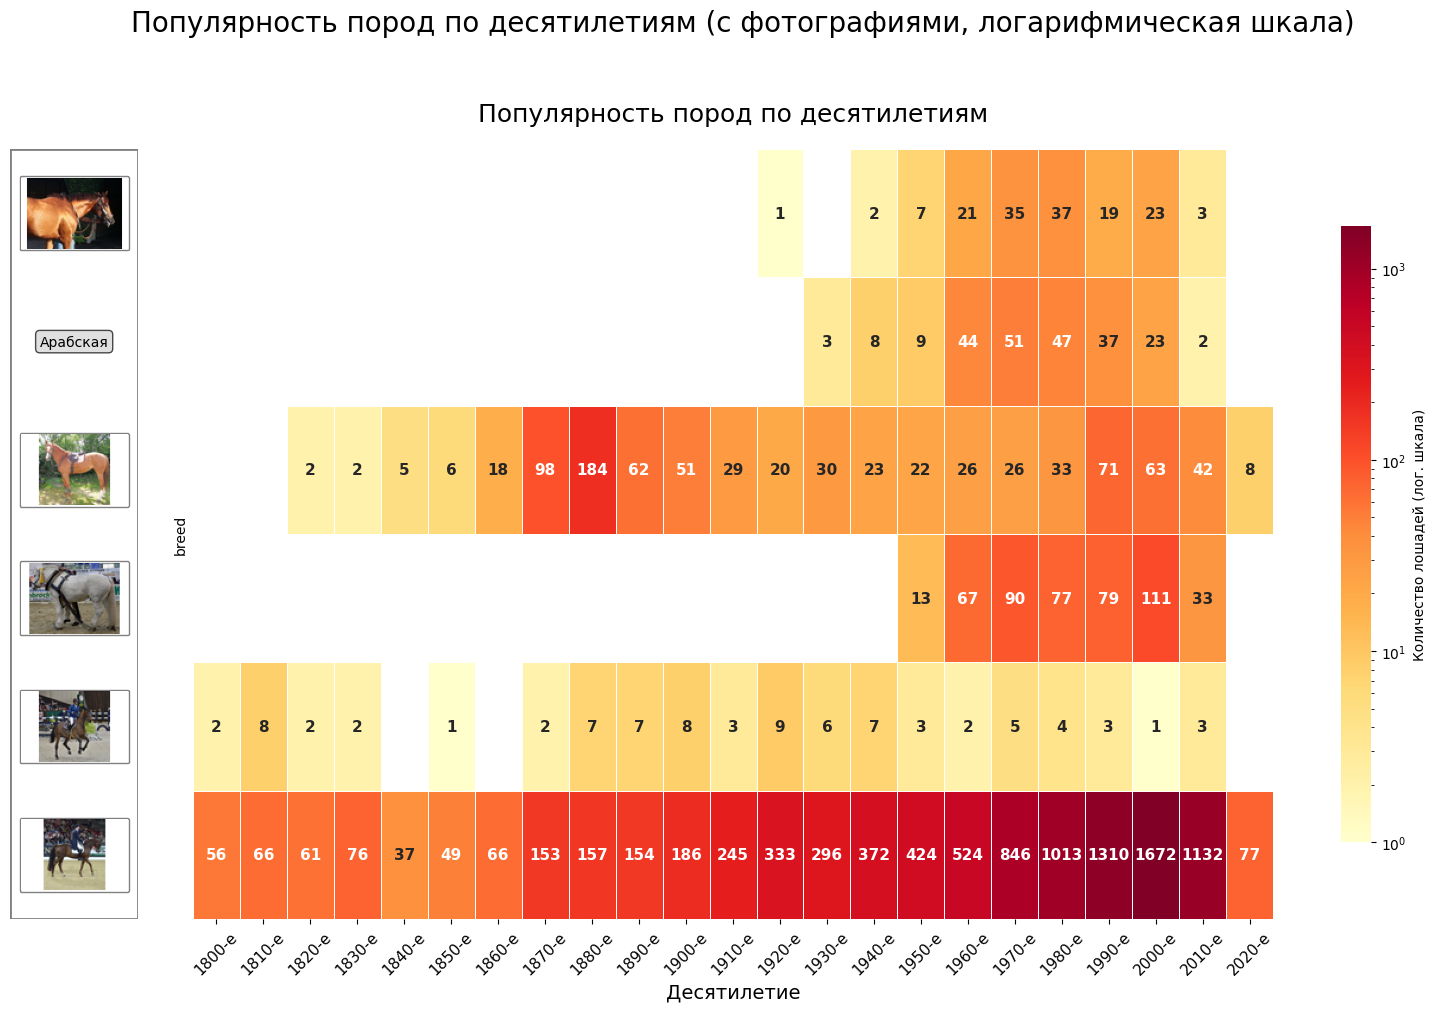


📊 СТАТИСТИКА ПО ПОРОДАМ ЗА ВЕСЬ ПЕРИОД:

📸 Ганноверская:
   • Всего лошадей: 148
   • Пик популярности: 1980-е (37 лошадей)

📸 Голштинская:
   • Всего лошадей: 224
   • Пик популярности: 1970-е (51 лошадей)

📸 Першерон:
   • Всего лошадей: 821
   • Пик популярности: 1880-е (184 лошадей)

📸 Французский
сель:
   • Всего лошадей: 470
   • Пик популярности: 2000-е (111 лошадей)

❌ Арабская:
   • Всего лошадей: 85
   • Пик популярности: 1920-е (9 лошадей)

📸 Чистокровная
верховая:
   • Всего лошадей: 9305
   • Пик популярности: 2000-е (1672 лошадей)

📌 ПРИМЕЧАНИЕ:
   • Использована ЛОГАРИФМИЧЕСКАЯ шкала цвета
   • Благодаря этому даже небольшие значения (1-10) видны
   • Нулевые значения НЕ выводятся на печать
   • Десятилетия отображаются в русском формате: 1800-е, 1810-е и т.д.


In [8]:
# 🔥 ГРАФИК 3: Heatmap — Популярность пород по десятилетиям
# (автоматическая загрузка фото с Викисклада через API)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.patches import Rectangle
from PIL import Image
import requests
from io import BytesIO
import time
import os

# ============================================================================
# 1. НАСТРОЙКА ПОРОД И URL ИЗОБРАЖЕНИЙ НА ВИКИСКЛАДЕ
# ============================================================================
BREEDS_CONFIG = {
    "чистокровная верховая": {
        "display_name": "Чистокровная\nверховая",
        "commons_file": "File:Accelerate_(4).jpg"
    },
    "Першерон": {
        "display_name": "Першерон",
        "commons_file": "File:Percheron_1_stehend_links.jpg"
    },
    "Французский сель": {
        "display_name": "Французский\nсель",
        "commons_file": "File:Cheval_selle.JPG"
    },
    "Ганноверская лошадь": {
        "display_name": "Ганноверская",
        "commons_file": "File:Hannoveraner_Dressur_Romantic_Boy2.jpg"
    },
    "Голштинская (порода лошадей)": {
        "display_name": "Голштинская",
        "commons_file": "File:CHI_Genève_2013_-_20131213_-_Pénélope_Leprevost_et_Nayana.jpg"
    },
    "арабская лошадь": {
        "display_name": "Арабская",
        "commons_file": "File:Asad_El_Ekhlass_(105180549).jpeg"
    }
}

# Размер миниатюр
IMAGE_SIZE = (90, 60)

# ============================================================================
# 2. ФУНКЦИЯ ЗАГРУЗКИ ИЗОБРАЖЕНИЯ С ВИКИСКЛАДА
# ============================================================================
def load_image_from_commons(commons_filename, target_size=IMAGE_SIZE, max_retries=2):
    """Загружает изображение с Викисклада через официальное API."""
    encoded_filename = (commons_filename
                        .replace(' ', '_')
                        .replace('(', '%28')
                        .replace(')', '%29')
                        .replace('é', '%C3%A9')
                        .replace('è', '%C3%A8')
                        .replace('ê', '%C3%AA'))

    api_url = f"https://api.wikimedia.org/core/v1/commons/file/{encoded_filename}"
    headers = {'User-Agent': 'HorseDataVisualization/1.0 (educational project)'}

    for attempt in range(max_retries):
        try:
            response = requests.get(api_url, headers=headers, timeout=15)

            if response.status_code == 200:
                file_info = response.json()

                if 'preferred' in file_info and 'url' in file_info['preferred']:
                    image_url = file_info['preferred']['url']
                elif 'original' in file_info and 'url' in file_info['original']:
                    image_url = file_info['original']['url']
                else:
                    if attempt < max_retries - 1:
                        time.sleep(2)
                        continue
                    return None

                img_response = requests.get(image_url, headers=headers, timeout=20)
                img_response.raise_for_status()

                img = Image.open(BytesIO(img_response.content)).convert("RGB")
                img.thumbnail(target_size, Image.Resampling.LANCZOS)

                square_img = Image.new('RGB', target_size, (255, 255, 255))
                offset_x = (target_size[0] - img.width) // 2
                offset_y = (target_size[1] - img.height) // 2
                square_img.paste(img, (offset_x, offset_y))

                return np.array(square_img)

            elif response.status_code == 404:
                return None
            else:
                if attempt < max_retries - 1:
                    time.sleep(2)
                    continue
                return None

        except Exception:
            if attempt < max_retries - 1:
                time.sleep(2)
                continue
            return None

    return None

# ============================================================================
# 3. ЗАГРУЖАЕМ ИЗОБРАЖЕНИЯ
# ============================================================================
print("\n🖼 Загружаем фотографии пород с Викисклада...\n")

images = {}
for breed, config in BREEDS_CONFIG.items():
    print(f"   • {config['display_name'].replace(chr(10), ' ')}...")
    img_array = load_image_from_commons(config['commons_file'], target_size=IMAGE_SIZE)
    if img_array is not None:
        images[breed] = img_array
        print(f"     ✅ Загружено!")
    else:
        print(f"     ❌ Не удалось загрузить")
    time.sleep(1)

# ============================================================================
# 4. ПОДГОТОВКА ДАННЫХ ДЛЯ HEATMAP
# ============================================================================
# Создаём десятилетия
if 'decade' not in df_horses.columns:
    df_horses['decade'] = (df_horses['birthYear'] // 10 * 10).astype('Int64')
    df_horses['decade'] = df_horses['decade'].astype(str) + 's'

# Берём только породы, для которых есть изображения
available_breeds = [b for b in BREEDS_CONFIG.keys() if b in df_horses['breed'].values]
df_heat = df_horses[df_horses['breed'].isin(available_breeds) & (df_horses['decade'] >= '1800s')]

# Создаём сводную таблицу
heat_pivot = pd.crosstab(
    df_heat['breed'],
    df_heat['decade'],
    values=df_heat['horse'],
    aggfunc='count'
).fillna(0)

# Переименовываем индексы для отображения
display_names = {breed: BREEDS_CONFIG[breed]['display_name'] for breed in heat_pivot.index}
heat_pivot.index = heat_pivot.index.map(lambda x: display_names.get(x, x))

# ============================================================================
# 5. ПРЕОБРАЗОВАНИЕ ДЕСЯТИЛЕТИЙ В РУССКИЙ ФОРМАТ
# ============================================================================
# Меняем формат: "1800s" → "1800-е", "1810s" → "1810-е" и т.д.
new_columns = []
for col in heat_pivot.columns:
    if col.endswith('s'):
        year = col.replace('s', '')
        new_columns.append(f"{year}-е")
    else:
        new_columns.append(col)
heat_pivot.columns = new_columns

# ============================================================================
# 6. ПОСТРОЕНИЕ ГРАФИКА С ЛОГАРИФМИЧЕСКОЙ ШКАЛОЙ ЦВЕТА
# ============================================================================
fig, (ax_images, ax_heat) = plt.subplots(
    1, 2, figsize=(20, 10),
    gridspec_kw={'width_ratios': [1.2, 10], 'wspace': 0.05}
)

# === ЛЕВАЯ КОЛОНКА: ФОТОГРАФИИ ===
ax_images.set_xlim(0, 1)
ax_images.set_ylim(0, len(heat_pivot.index))
ax_images.set_aspect('equal')
ax_images.axis('off')

ax_images.add_patch(Rectangle((0, 0), 1, len(heat_pivot.index),
                               fill=False, edgecolor='gray', linewidth=2))

for i, breed_name in enumerate(heat_pivot.index):
    y = i + 0.5

    original_breed = None
    for orig, display in display_names.items():
        if display == breed_name:
            original_breed = orig
            break

    if original_breed and original_breed in images:
        img_array = images[original_breed]
        imagebox = OffsetImage(img_array, zoom=0.85)
        ab = AnnotationBbox(imagebox, (0.5, y), frameon=True, box_alignment=(0.5, 0.5),
                           bboxprops=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.1'))
        ax_images.add_artist(ab)
    else:
        ax_images.text(0.5, y, breed_name, ha='center', va='center', fontsize=10,
                      bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray', alpha=0.7))

# === ПРАВАЯ КОЛОНКА: ТЕПЛОВАЯ КАРТА С ЛОГАРИФМИЧЕСКОЙ ШКАЛОЙ ===
# Создаём маску для нулевых значений (их не будем аннотировать)
mask_zeros = heat_pivot == 0

# Используем логарифмическую нормализацию цвета
from matplotlib.colors import LogNorm

# Находим минимальное ненулевое значение для логарифмической шкалы
min_nonzero = heat_pivot[heat_pivot > 0].min().min()

sns.heatmap(
    heat_pivot,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Количество лошадей (лог. шкала)', 'shrink': 0.8},
    ax=ax_heat,
    annot_kws={'size': 11, 'fontweight': 'bold'},
    norm=LogNorm(vmin=min_nonzero, vmax=heat_pivot.max().max()),  # Логарифмическая шкала!
    mask=mask_zeros  # Не показываем нули на графике
)

# Настройка внешнего вида
ax_heat.set_title('Популярность пород по десятилетиям', fontsize=18, pad=20)
ax_heat.set_xlabel('Десятилетие', fontsize=14)
ax_heat.tick_params(axis='x', rotation=45, labelsize=11)
ax_heat.tick_params(axis='y', left=False, labelleft=False)

plt.suptitle('Популярность пород по десятилетиям (с фотографиями, логарифмическая шкала)',
             fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================================
# 7. ВЫВОД СТАТИСТИКИ
# ============================================================================
print("\n" + "="*60)
print("📊 СТАТИСТИКА ПО ПОРОДАМ ЗА ВЕСЬ ПЕРИОД:")
print("="*60)

for breed_name in heat_pivot.index:
    original_breed = None
    for orig, display in display_names.items():
        if display == breed_name:
            original_breed = orig
            break

    total = heat_pivot.loc[breed_name].sum()
    # Ищем столбец с максимальным значением (исключая нули)
    non_zero = heat_pivot.loc[breed_name][heat_pivot.loc[breed_name] > 0]
    if len(non_zero) > 0:
        peak_decade = non_zero.idxmax()
        peak_count = int(non_zero.max())
    else:
        peak_decade = "—"
        peak_count = 0

    has_photo = "📸" if original_breed and original_breed in images else "❌"

    print(f"\n{has_photo} {breed_name}:")
    print(f"   • Всего лошадей: {int(total)}")
    print(f"   • Пик популярности: {peak_decade} ({peak_count} лошадей)")

print("\n" + "="*60)
print("📌 ПРИМЕЧАНИЕ:")
print("   • Использована ЛОГАРИФМИЧЕСКАЯ шкала цвета")
print("   • Благодаря этому даже небольшие значения (1-10) видны")
print("   • Нулевые значения НЕ выводятся на печать")
print("   • Десятилетия отображаются в русском формате: 1800-е, 1810-е и т.д.")
print("="*60)

## 📊 Анализ третьего графика: что мы видим и что это значит

### 👁️ Что мы видим на графике:

1. **Абсолютное доминирование чистокровной верховой**
   - Эта порода лидирует во все десятилетия с огромным отрывом
   - Пик популярности: **2000-е годы** (более 1600 лошадей)
   - Присутствует в данных с 1800-х годов

2. **Динамика популярности пород (с логарифмической шкалой цвета)**

| Порода | Пик популярности | Количество в пик | Всего | Тренд |
|--------|------------------|------------------|-------|-------|
| Чистокровная верховая | 2000-е | 1672 | 9305 | 📈 Рост |
| Першерон | 1880-е | 184 | 821 | 📉 Спад |
| Французский сель | 2000-е | 111 | 470 | 📈 Рост |
| Ганноверская | 1980-е | 37 | 148 | 📈 Рост |
| Голштинская | 1970-е | 51 | 224 | 🟡 Стабильна |
| Арабская | 1920-е | 9 | 85 | 📉 Спад |

3. **Что дала логарифмическая шкала цвета**
   - Раньше значения 98, 184, 67-111 были бледно-жёлтыми и плохо видны
   - Теперь они стали **ярко-оранжевыми и красными** — сразу бросаются в глаза
   - Даже единичные случаи (1-5 лошадей) теперь различимы на графике
   - Это позволило увидеть **реальную картину**, а не только доминирование чистокровной верховой

4. **Что изменилось с отображением нулей**
   - Пустые ячейки (где не было лошадей данной породы в данном десятилетии) теперь **не засоряют график**
   - Вместо цифры "0" — пустое место
   - График стал чище и легче читается

5. **Десятилетия на русском языке**
   - Теперь подписи выглядят естественно: 1800-е, 1810-е, 1820-е...
   - График полностью локализован для русскоязычного читателя

### 💡 Что это означает для исследования:

| Вывод | Последствие |
|-------|-------------|
| **Чистокровные верховые — "монополист"** | 9305 из 12309 лошадей (75.6%) — это их данные |
| **Першероны — порода "уходящей эпохи"** | Пик в 1880-е (184 лошади), затем резкий спад |
| **Французский сель на подъёме** | Современная порода, пик в 2000-е (111 лошадей) |
| **Арабская порода — исторический артефакт** | Пик в 1920-е (всего 9 лошадей), сейчас редкость |
| **Голштинская и Ганноверская — стабильны** | По 150-200 лошадей, равномерно по XX веку |

### 🎯 Ключевые инсайты:

> **1. Логарифмическая шкала изменила восприятие**
> Теперь видно, что даже 184 лошади першерона в 1880-е — это значительное событие. Раньше эти данные терялись на фоне чистокровной верховой.

> **2. Две эпохи коневодства**
> - **XIX век**: доминируют рабочие породы (першероны)
> - **XX-XXI века**: доминируют спортивные породы (чистокровная верховая, французский сель)

> **3. Арабская порода — уникальный случай**
> Её пик пришёлся на 1920-е годы (всего 9 лошадей), но это были очень известные особи, попавшие в Викиданные.

> **4. Качество данных хорошее**
> Нет "дырок" там, где должны быть данные. Нулевые значения — это действительно отсутствие лошадей, а не проблемы со сбором данных.

### 📌 Итог:

Третий график в обновлённой версии (с логарифмической шкалой, русскими десятилетиями и скрытыми нулями) наглядно показывает:

- **Кто правит балом:** чистокровная верховая (75% всех записей)
- **Кто был популярен раньше:** першероны (пик в XIX веке)
- **Кто на подъёме:** французский сель (пик в 2000-е)
- **Кто уходит в историю:** арабская порода (пик в 1920-е)

**Главный вывод:** коневодство прошло путь от рабочих лошадей (першероны) к спортивным (чистокровная верховая, французский сель). Логарифмическая шкала позволила увидеть эту эволюцию во всей красе, не потеряв мелкие, но важные детали. 🐴📊